In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
from matplotlib import pyplot as plt

# --! import KIND framework files --!

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--dataset_id', 'kind-detuning-filter',
        '--file_dir', '../../data/kalman',
        '--file_name', 'tesla_sim',
        '--data_nsample', '500',
        '--feature_ndim', '3',
        '--target_ndim', '1',

        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '32',
        '--nepoch', '100',
        '--patience', '10',
        '--checkpoints', '../../models/kalman/filter',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 5, "cos": 5}',
        '--fun_trans', '{"sin": 5, "cos": 5}',
        '--nneuron_stat', '64',
        '--nlayer_stat', '2',
    ]
)

In [3]:
model = kind.model(args)
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model.train()
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=1.320693, valid=0.086134, test=0.080729
	validation loss decreased (inf -> 0.086134), saving model ...
	epoch 2 losses: train=0.708073, valid=0.069174, test=0.063647
	validation loss decreased (0.086134 -> 0.069174), saving model ...
	epoch 3 losses: train=0.663033, valid=0.067018, test=0.061207
	validation loss decreased (0.069174 -> 0.067018), saving model ...
	epoch 4 losses: train=0.455922, valid=0.033346, test=0.032093
	validation loss decreased (0.067018 -> 0.033346), saving model ...
	epoch 5 losses: train=0.244546, valid=0.021790, test=0.021063
	validation loss decreased (0.033346 -> 0.021790), saving model ...
	epoch 6 losses: train=0.232851, valid=0.020324, test=0.019757
	validation loss decreased (0.021790 -> 0.020324), saving model ...
	epoch 7 losses: train=0.229411, valid=0.019833, test=0.019361
	validation loss decreased (0.020324 -> 0.019833), saving model ...
	epoch 8 losses: train=0.228151, valid=0.021108, test=0.02

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

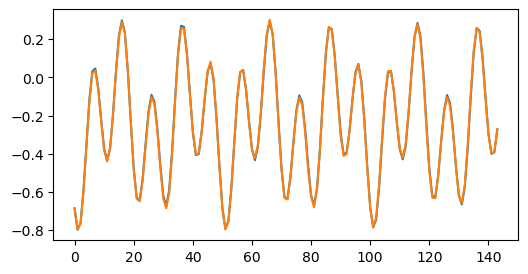

In [6]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break